In [1]:
# Cell 1: Environment Setup & GPU Verification (TDD)
# Project: HallucinationLegalRAGChatbots
#
# Purpose
# -------
# One-time environment gate for the Harvard ODD GPU cluster notebook.
# Locates the project root, loads .env (TARGET_GPU_COUNT, reproducibility
# flags), configures deterministic training via src/repro.configure(),
# then runs the full TDD environment contract + preflight hard gate
# before any expensive GPU work begins.
#
# What it does
# ------------
# Step 0 — Project root + PATH (must be FIRST — before torch import):
#   1. Walks up from cwd until pyproject.toml is found (idempotent —
#      safe to re-run without drifting past root).
#   2. Prepends .venv/bin to PATH so subprocess calls to venv CLI tools
#      (dvc, uv, pytest) resolve correctly — Jupyter kernel inherits a
#      minimal PATH that excludes the venv's bin dir.
#   3. Loads .env via dotenv so preflight sees TARGET_GPU_COUNT,
#      TARGET_VRAM_GB_MIN, PYTHONHASHSEED, CUBLAS_WORKSPACE_CONFIG,
#      TOKENIZERS_PARALLELISM (override=False — repro.configure wins).
#   4. Calls src.repro.configure() — sets PYTHONHASHSEED, CUBLAS config,
#      TOKENIZERS_PARALLELISM, torch.use_deterministic_algorithms,
#      cuDNN flags, and seeds all RNGs. Guarantees notebook/CLI parity.
#
# Step 1 — Environment contract + preflight:
#   5. run_environment_checks() — TDD RED→GREEN gate: imports every
#      REQUIRED_DEPS entry, verifies version constraints, checks CUDA
#      availability, VRAM floor, and cross-package compatibility.
#   6. run_preflight_checks() — hard gate validating 9 conditions:
#      GPU count (exact match with TARGET_GPU_COUNT), compute cap,
#      VRAM, torch CUDA runtime, disk space, src/repro.py integrity,
#      repro_cfg dict, torch determinism flags, OS env vars, uv.lock.
#      Raises PreflightError with actionable message on any failure.
#   7. Logs repro config summary and verified environment table.
#
# Clean Code: Thin orchestration. All logic in src/environment.py.
# No side effects on import — checks wrapped in run_environment_checks().
#
# Reproducibility: src/repro.configure() MUST be called first — before any
# import of torch, transformers, or other ML libraries. This guarantees
# notebook/CLI parity: identical PYTHONHASHSEED, CUBLAS_WORKSPACE_CONFIG,
# TOKENIZERS_PARALLELISM, torch.use_deterministic_algorithms, and cuDNN flags
# regardless of whether the code runs in JupyterLab or from the CLI.
# See src/repro.py for full rationale.
#
# Failure isolation: run_preflight_checks() is a hard gate that validates ALL
# critical preconditions BEFORE any expensive GPU training begins. This prevents
# wasted GPU hours from misconfigured environments discovered mid-run.
# If preflight fails, the notebook raises immediately with an actionable message.
#
# Harvard cluster context
# -----------------------
# The notebook runs on the HallucinationLegalRAG Jupyter kernel, which IS
# .venv/bin/python (registered by setup.sh). All imports execute directly
# in the pinned venv — no subprocess-via-.venv wrapper needed (unlike the
# Colab version). TARGET_GPU_COUNT is resolved dynamically at setup time
# from CUDA_VISIBLE_DEVICES (or nvidia-smi count) and written to .env,
# so the same notebook works on 1-GPU SLURM jobs and 4-GPU interactive nodes.
#
# Runtime
# -------
# ~25-30s (dominated by dependency import verification and GPU preflight).
import os
import sys
from pathlib import Path

# Locate project root by walking up until pyproject.toml is found.
# Idempotent: safe to re-run the cell without drifting further up.
_here = Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "pyproject.toml").exists()), None)
assert _root is not None, f"pyproject.toml not found at or above {_here}"
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# Prepend .venv/bin to PATH so subprocess calls to venv CLI tools (dvc, uv,
# pytest, etc.) resolve correctly. Jupyter kernel inherits a minimal PATH
# that excludes the venv's bin dir even though the kernel's Python IS the
# venv's interpreter.
_venv_bin = str(_root / ".venv" / "bin")
if _venv_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{_venv_bin}:{os.environ['PATH']}"

# Load .env so preflight sees TARGET_GPU_COUNT, TARGET_VRAM_GB_MIN,
# PYTHONHASHSEED, CUBLAS_WORKSPACE_CONFIG, TOKENIZERS_PARALLELISM.
# override=False → repro.configure() still wins for repro-critical vars.
from dotenv import load_dotenv
load_dotenv(_root / ".env", override=False)

from src.repro import configure as _configure_repro
repro_cfg = _configure_repro(verbose=True)
# --- Step 1: Remaining imports (torch now imported safely after repro config) ---
import logging
from src.environment import (
    REQUIRED_DEPS,
    get_environment_summary,
    run_environment_checks,
    run_preflight_checks,
)
from src.timer import cell_timer
logger = logging.getLogger("cell1")
logger.setLevel(logging.INFO)
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("  %(message)s"))
    logger.addHandler(handler)
with cell_timer("Cell 1 — Environment Setup & GPU Verification", logger=logger):
    # --- TDD Contract ---
    logger.info("=" * 60)
    logger.info("  TDD RED→GREEN: Environment Contract")
    logger.info("=" * 60)
    assert run_environment_checks(logger=logger), "Environment contract violated"
    # --- Preflight Gate (hard stop before any expensive training) ---
    # Validates: GPU count/name/VRAM, disk space, repro config integrity,
    # uv.lock hash match, and src/repro.py presence.
    # Raises PreflightError with actionable message on any failure.
    logger.info(f"\n{'=' * 60}")
    logger.info("  Preflight Checks — Failure Isolation Gate")
    logger.info("=" * 60)
    run_preflight_checks(logger=logger, repro_cfg=repro_cfg)
    # --- Repro Config Summary ---
    logger.info(f"\n{'=' * 60}")
    logger.info("  Reproducibility Config (src/repro.configure)")
    logger.info("=" * 60)
    for k, v in repro_cfg.items():
        logger.info(f"  {k:<36} {v}")
    # --- Environment Summary ---
    env = get_environment_summary()
    logger.info(f"\n{'=' * 60}")
    logger.info("  Verified Environment")
    logger.info("=" * 60)
    for pkg, constraint in REQUIRED_DEPS.items():
        logger.info(f"  {pkg:<16} {env[pkg]:<12} (requires {constraint or 'any'})")
    logger.info(f"  {'GPU':<16} {env['gpu']}")
    logger.info(f"  {'GPU Memory':<16} {env['gpu_memory_gb']} GB")
    logger.info(f"  {'CUDA':<16} {env['cuda']}")
    logger.info("\n✓ Environment ready — all preflight checks passed, safe to proceed")

    TDD RED→GREEN: Environment Contract


  [repro] Reproducibility configured:
    PYTHONHASHSEED=0
    CUBLAS_WORKSPACE_CONFIG=:4096:8
    TOKENIZERS_PARALLELISM=false
    deterministic_algorithms=True
    cudnn_benchmark=False
    cudnn_deterministic=True
    random_seed=0
    torch.cuda.manual_seed_all(0) → 1 GPU(s)


  ✓ PASS: Every required dependency must be importable and meet version constraints
  ✓ PASS: CUDA GPU must be detected for training
  ✓ PASS: GPU must have at least 10GB VRAM for transformer fine-tuning
  ✓ PASS: PyTorch must be compiled with CUDA support
  ✓ PASS: Cross-dependency version constraints must be satisfied
  
    Preflight Checks — Failure Isolation Gate
  ✓ PASS: GPU count 1 == TARGET_GPU_COUNT=1 (exact)
  ✓ PASS: GPU[0] NVIDIA L4 | cap (8, 9) | 23.7GB
  ✓ PASS: torch CUDA runtime 11.7
  ✓ PASS: Disk 9223360574.1GB free
  ✓ PASS: src/repro.py importable
  ✓ PASS: repro_cfg['PYTHONHASHSEED'] = '0'
  ✓ PASS: repro_cfg['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
  ✓ PASS: repro_cfg['TOKENIZERS_PARALLELISM'] = 'false'
  ✓ PASS: repro_cfg['deterministic_algorithms'] = True
  ✓ PASS: repro_cfg['cudnn_benchmark'] = False
  ✓ PASS: repro_cfg['cudnn_deterministic'] = True
  ✓ PASS: torch runtime state — deterministic
  ✓ PASS: os.environ['PYTHONHASHSEED'] = '0'
  ✓ PASS: os.environ['C

In [2]:
# Cell 2: Verify CL bulk data directory on Harvard cluster filesystem
"""
Purpose
-------
Ensures the CourtListener bulk CSV archive directory exists and reports
any existing archives with sizes, so warm-start runs confirm data
presence before the download cell attempts S3 fetches. Also checks
available disk space — the full CL bulk snapshot requires ~60 GB.

What it does
------------
1. Creates data/raw/cl_bulk/ if it does not already exist (idempotent).
2. Reports filesystem free/total space so the user can confirm
   sufficient capacity before attempting the CL bulk download.
3. Lists any existing .csv.bz2 archives with sizes — useful to confirm
   a warm-start run already has the bulk archives from a prior session.

Filesystem layout
-----------------
data/raw/cl_bulk/
    courts-2025-12-31.csv.bz2          (~1 KB)
    dockets-2025-12-31.csv.bz2         (~4.9 GB)
    opinion-clusters-2025-12-31.csv.bz2 (~2.5 GB)
    opinions-2025-12-31.csv.bz2        (~53.7 GB)

Harvard cluster home directories persist across sessions, so archives
survive runtime resets without Drive mounts or symlinks. The download
cell writes directly into this directory.

Runtime
-------
<1s (directory creation + stat calls only).
"""
import shutil, time
from pathlib import Path

_t_start = time.perf_counter()

cl_bulk = Path("data/raw/cl_bulk")
cl_bulk.mkdir(parents=True, exist_ok=True)
print(f"cl_bulk dir: {cl_bulk.resolve()}")

total, used, free = shutil.disk_usage(cl_bulk)
print(f"filesystem free: {free/1e9:.1f} GB / total: {total/1e9:.1f} GB")

archives = sorted(cl_bulk.glob("*.csv.bz2"))
if archives:
    print(f"existing archives ({len(archives)}):")
    for p in archives:
        print(f"  {p.name}  {p.stat().st_size/1e9:.2f} GB")
else:
    print("no archives yet — Cell 5 bulk_download will fetch from CourtListener")

print(f"⏱ Cell 2: Verify CL bulk data directory on Harvard cluster filesystem completed in {time.perf_counter() - _t_start:.1f}s")

cl_bulk dir: /shared/home/phl690/cs1090b_HallucinationLegalRAGChatbots/data/raw/cl_bulk
filesystem free: 9223360574.1 GB / total: 9223372036.9 GB
existing archives (4):
  courts-2025-12-31.csv.bz2  0.00 GB
  dockets-2025-12-31.csv.bz2  4.88 GB
  opinion-clusters-2025-12-31.csv.bz2  2.45 GB
  opinions-2025-12-31.csv.bz2  53.70 GB
⏱ Cell 2: Verify CL bulk data directory on Harvard cluster filesystem completed in 0.0s


In [3]:
# Cell 3: CourtListener bulk CSV download — filesystem-persistent, skip if present
"""
Purpose
-------
Downloads the 4 CourtListener bulk CSV archives (courts, dockets,
opinion-clusters, opinions) into data/raw/cl_bulk/. Idempotent: if all
4 archives are already present, skips the download entirely. Otherwise
uses the pinned 2025-12-31 snapshot (matching the pipeline cell's
manifest) via config.pinned_files to download only what's missing.

What it does
------------
1. Instantiates PipelineConfig with pinned 2025-12-31 S3 object keys.
2. Checks which of {courts-, dockets-, opinion-clusters-, opinions-}
   archives already exist in cfg.bulk_dir.
3. If all 4 present: logs sizes and skips — no network I/O.
4. Otherwise: uses cfg.pinned_files (no S3 discovery), then calls
   download_bulk_csvs() for the missing set, logs destination paths.

Snapshot pinning (2025-12-31)
-----------------------------
Pinning to 2025-12-31 matches the pre-processed shards + manifest
already on the Harvard cluster filesystem. Without pinning, S3
discovery finds a newer snapshot and triggers a cold re-extraction.
With pinning, the pipeline cell's fast-path sees matching source_files
in the manifest and skips immediately.

Filesystem layout
-----------------
data/raw/cl_bulk/
    courts-2025-12-31.csv.bz2          (~1 KB)
    dockets-2025-12-31.csv.bz2         (~4.9 GB)
    opinion-clusters-2025-12-31.csv.bz2 (~2.5 GB)
    opinions-2025-12-31.csv.bz2        (~53.7 GB)

Harvard cluster home directories persist across sessions, so archives
survive runtime resets without Drive mounts or symlinks. All imports
run directly in the kernel (which IS .venv/bin/python) — no subprocess
wrapper needed.

Runtime
-------
Warm start (all archives present): <1s (directory scan + size log).
Cold start (full download): ~15-40 min depending on S3 throughput and
the total archive size (~60 GB compressed).
"""
import logging, time
from src.config import PipelineConfig
from src.bulk_download import download_bulk_csvs

_t_start = time.perf_counter()
logging.basicConfig(level=logging.INFO, format="  %(message)s")
log = logging.getLogger("bulk")

cfg = PipelineConfig(
    pinned_courts="bulk-data/courts-2025-12-31.csv.bz2",
    pinned_dockets="bulk-data/dockets-2025-12-31.csv.bz2",
    pinned_clusters="bulk-data/opinion-clusters-2025-12-31.csv.bz2",
    pinned_opinions="bulk-data/opinions-2025-12-31.csv.bz2",
)
cfg.bulk_dir.mkdir(parents=True, exist_ok=True)
log.info("Snapshot: pinned 2025-12-31 (matches manifest)")

need = {"courts-", "dockets-", "opinion-clusters-", "opinions-"}
have = {p.name for p in cfg.bulk_dir.glob("*.csv.bz2")}
matched = {lbl for lbl in need if any(n.startswith(lbl) for n in have)}

if matched == need:
    log.info(f"All 4 bulk CSVs already present in {cfg.bulk_dir} — skipping")
    for p in sorted(cfg.bulk_dir.glob("*.csv.bz2")):
        log.info(f"  {p.name}  {p.stat().st_size / 1e9:.2f} GB")
else:
    log.info(f"Missing: {sorted(need - matched)}")
    latest = cfg.pinned_files
    for label, info in latest.items():
        log.info(f"  {label:<10} {info['key']}")
    paths = download_bulk_csvs(latest, config=cfg, logger=log)
    for label, p in paths.items():
        log.info(f"  {label:<10} -> {p}")

print(f"⏱ Cell 3: CourtListener bulk CSV download — filesystem-persistent, skip if present completed in {time.perf_counter() - _t_start:.1f}s")

  Snapshot: pinned 2025-12-31 (matches manifest)
  All 4 bulk CSVs already present in data/raw/cl_bulk — skipping
    courts-2025-12-31.csv.bz2  0.00 GB
    dockets-2025-12-31.csv.bz2  4.88 GB
    opinion-clusters-2025-12-31.csv.bz2  2.45 GB
    opinions-2025-12-31.csv.bz2  53.70 GB


⏱ Cell 3: CourtListener bulk CSV download — filesystem-persistent, skip if present completed in 0.0s


In [4]:
# Cell 4: Filter chain + extraction + manifest (Harvard filesystem-persistent shards)
"""
Purpose
-------
End-to-end Stage 1-2 data pipeline: pinned snapshot → filter chain →
extract → manifest → TDD contract tests. Produces the filesystem-
persistent NDJSON shards that downstream embedding, training, and
evaluation cells operate on.

Fast-path behavior
------------------
If manifest.json and all referenced shards are already present in the
shard directory (e.g. pre-processed on a prior Harvard ODD GPU Cluster
L4 session), run_pipeline() returns immediately without re-running any
stage. Otherwise runs the full pipeline:
  1. Pinned snapshot — use cfg.pinned_files (no S3 discovery)
  2. Download        — fetch missing archives into data/raw/cl_bulk
  3. Filter chain    — court → docket → cluster → opinion joins,
                       restricted to federal appellate circuits
  4. Extract         — per-opinion text extraction (html/plain/xml),
                       quarantine for per-row failures
  5. Manifest        — write manifest.json with provenance
                       (git rev, snapshot id, court distribution, stats)
  6. Contract tests  — validate_pipeline() runs TDD invariants
                       against the manifest and a sample of shards

Snapshot pinning (2025-12-31)
-----------------------------
PipelineConfig is pinned to the 2025-12-31 CL bulk snapshot, which
matches the pre-processed shards + manifest already on the Harvard
cluster filesystem. Without pinning, run_pipeline calls
discover_latest_bulk_files() which finds a newer snapshot on S3, sees
the manifest's source_files don't match, and triggers a cold
re-extraction. With pinning, the fast-path check succeeds immediately
and the cell returns in <30s.

Filesystem layout
-----------------
data/raw/cl_federal_appellate_bulk/
    shard_0000.jsonl ... shard_NNNN.jsonl
    manifest.json

Harvard cluster home directories persist across sessions, so no
Drive mount or symlink is needed — shards survive runtime resets.

Post-manifest infrastructure hooks
-----------------------------------
Three hooks (all TDD-covered in src/):
  - src.dvc_tracking   : version the shard directory with DVC
  - src.dataset_card   : emit HF Hub README.md from the manifest
  - src.data_contracts : statistical gates (row floor, court balance,
                         text length distribution)

Runtime
-------
Warm start (shards + manifest valid, pinned): ~10-30s (manifest parse +
contract tests on sampled shards).
Cold start (full pipeline from pinned snapshot): ~30-90 min on the
Harvard ODD L4 node (48-core AMD EPYC, 182 GB RAM).
"""
import logging, sys
from src.config import PipelineConfig
from src.data_contracts import run_all_contracts
from src.dataset_card import write_dataset_card
from src.dvc_tracking import DVCTrackingError, track_shard_directory
from src.pipeline import run_pipeline, validate_pipeline
from src.timer import cell_timer

def _get_cell_logger():
    lg = logging.getLogger("cell_pipeline")
    lg.setLevel(logging.INFO)
    if not lg.handlers:
        h = logging.StreamHandler(sys.stdout)
        h.setFormatter(logging.Formatter("  %(message)s"))
        lg.addHandler(h)
    lg.propagate = False
    return lg

logger = _get_cell_logger()
cfg = PipelineConfig(
    pinned_courts="bulk-data/courts-2025-12-31.csv.bz2",
    pinned_dockets="bulk-data/dockets-2025-12-31.csv.bz2",
    pinned_clusters="bulk-data/opinion-clusters-2025-12-31.csv.bz2",
    pinned_opinions="bulk-data/opinions-2025-12-31.csv.bz2",
)

with cell_timer("Cell 4: Pipeline (filter + extract + manifest)", logger=logger):
    logger.info("=" * 60)
    logger.info("  run_pipeline (pinned 2025-12-31; fast-path if manifest + shards valid)")
    logger.info("=" * 60)
    manifest = run_pipeline(config=cfg, logger=logger)

    logger.info("\n" + "=" * 60)
    logger.info("  validate_pipeline (TDD contract tests)")
    logger.info("=" * 60)
    validate_pipeline(config=cfg, manifest_data=manifest, logger=logger, shard_strategy="sample")
    logger.info("OK contract tests passed")

    logger.info("\n" + "=" * 60)
    logger.info("  DVC tracking (src.dvc_tracking)")
    logger.info("=" * 60)
    try:
        track_shard_directory(cfg.shard_dir, repo_root=".", push=False)
        logger.info("  OK shard_dir versioned (or already tracked)")
    except DVCTrackingError as e:
        logger.info(f"  SKIP dvc: {e}")

    logger.info("\n" + "=" * 60)
    logger.info("  HF dataset card (src.dataset_card)")
    logger.info("=" * 60)
    card_path = write_dataset_card(manifest, cfg.shard_dir)
    logger.info(f"  OK wrote {card_path}")

    logger.info("\n" + "=" * 60)
    logger.info("  Statistical data contracts (src.data_contracts)")
    logger.info("=" * 60)
    for r in run_all_contracts(manifest, strict=False):
        status = "PASS" if r.passed else "FAIL"
        logger.info(f"  {r.name:<28} {status} - {r.message}")

    logger.info("\n" + "=" * 60)
    logger.info("  Summary")
    logger.info("=" * 60)
    logger.info(f"  snapshot: {manifest['source_files']['opinions']}")
    logger.info(f"  git_rev:  {manifest['run_metadata']['git_revision'][:12]}")
    logger.info(f"  shards:   {manifest['num_shards']}")
    logger.info(f"  cases:    {manifest['num_cases']:,}")
    logger.info(f"  scanned:  {manifest.get('scanned', 0):,}")
    logger.info(f"  circuits: {len(manifest.get('court_distribution', {}))}")
    tls = manifest.get("text_length_stats", {})
    if tls:
        logger.info(f"  text len: mean={tls.get('mean', 0):,} median={tls.get('median', 0):,} p95={tls.get('p95', 0):,}")

    run_pipeline (pinned 2025-12-31; fast-path if manifest + shards valid)
  ✓ Already complete: 1,465,484 cases, 159 shards verified
  
    validate_pipeline (TDD contract tests)
  ✓ PASS: Shard directory must exist
  ✓ PASS: Manifest must exist
  ✓ PASS: At least one shard present
  ✓ PASS: Sufficient opinions
  ✓ PASS: Valid JSON
  ✓ PASS: Text present
  ✓ PASS: Text substantive
  ✓ PASS: Provenance metadata
  ✓ PASS: Raw + normalized text + flags
  ✓ PASS: Text source tracked
  ✓ PASS: Multiple circuits
  ✓ PASS: Schema consistent
  ✓ PASS: Checksums match
  OK contract tests passed
  
    DVC tracking (src.dvc_tracking)
    SKIP dvc: dvc add failed (exit 1): ERROR: bad DVC file name 'data/raw/cl_federal_appellate_bulk.dvc' is git-ignored.
  
    HF dataset card (src.dataset_card)
    OK wrote data/raw/cl_federal_appellate_bulk/README.md
  
    Statistical data contracts (src.data_contracts)
    row_count_floor              PASS - 1,465,484 >= 10,000
    court_balance              

    scripts.eda_ms3_corpus.main()  (thin orchestration)
[eda_ms3] Scanning data/raw/cl_federal_appellate_bulk/shard_*.jsonl via Polars lazy scan...
[eda_ms3] Wrote 4 figures + summary.json to logs/eda_ms3/
  
    MS3 EDA Figures
    Displaying text_length_hist.png  (33.2 KB)


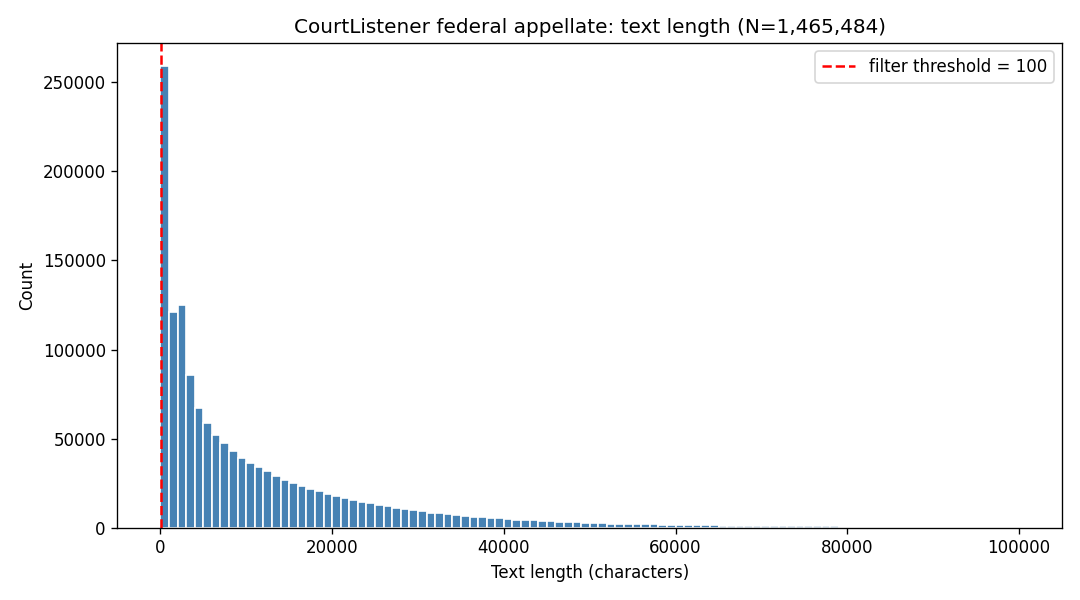

    Displaying text_length_hist_log.png  (30.8 KB)


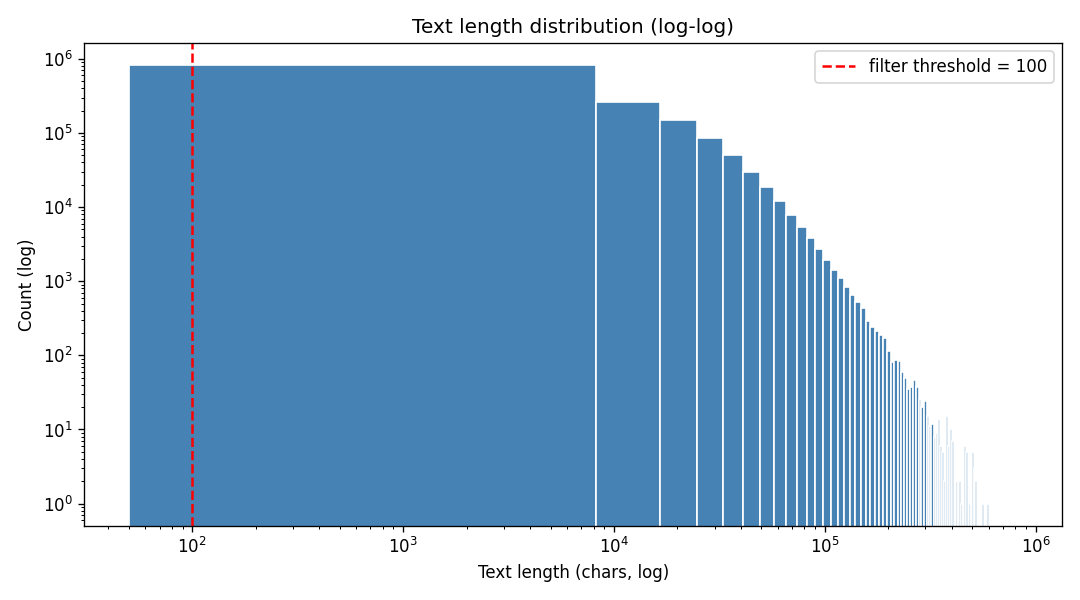

    Displaying circuit_distribution.png  (41.9 KB)


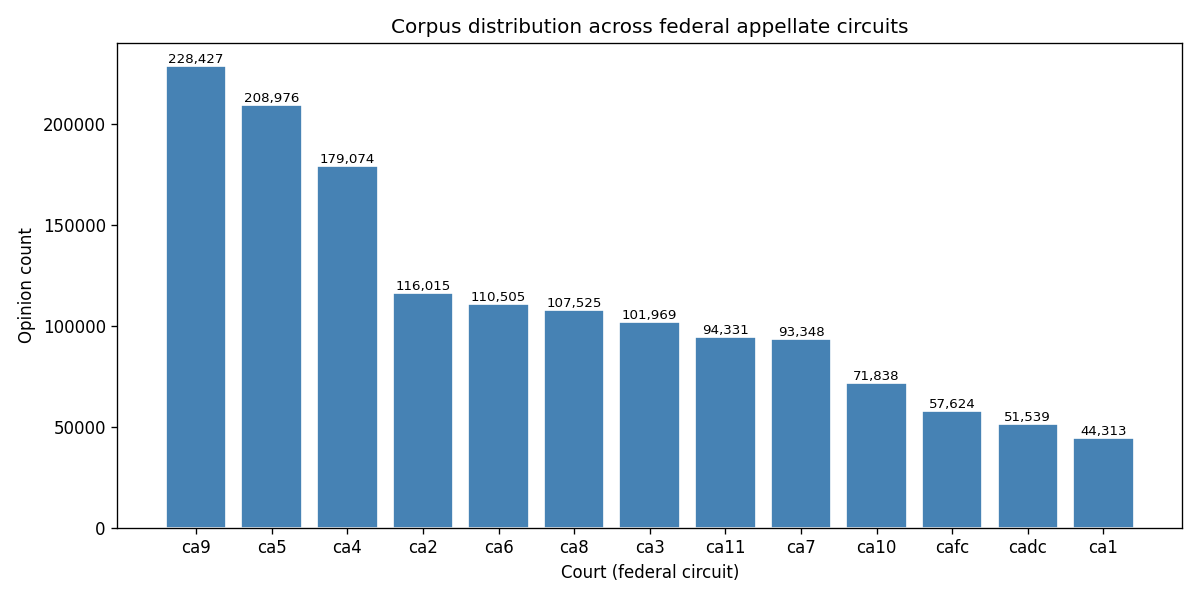

    Displaying citation_density.png  (27.2 KB)


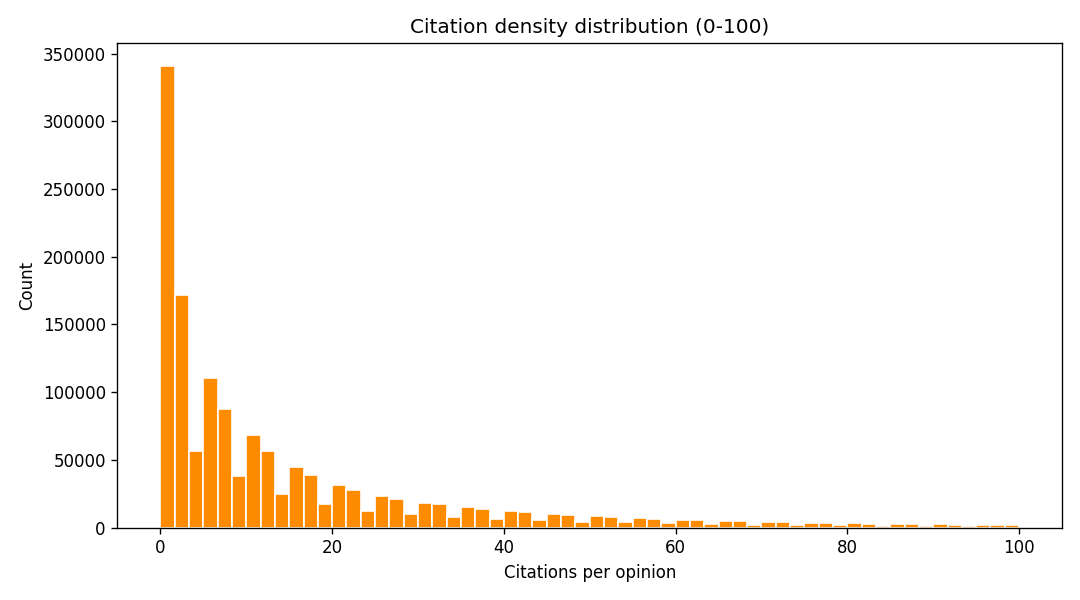

  
    summary.json  (SummarySchema-validated)
  {
  "n_total": 1465484,
  "text_length_mean": 12653.808420289815,
  "text_length_median": 6292.0,
  "n_short_lt_100": 5574,
  "schema_version": "1.0.0",
  "filter_threshold": 100,
  "circuit_counts": {
    "ca9": 228427,
    "ca5": 208976,
    "ca4": 179074,
    "ca2": 116015,
    "ca6": 110505,
    "ca8": 107525,
    "ca3": 101969,
    "ca11": 94331,
    "ca7": 93348,
    "ca10": 71838,
    "cafc": 57624,
    "cadc": 51539,
    "ca1": 44313
  },
  "corpus_manifest_sha": "b4377920365735583cad97734c32928a01018f64f7625c88680f537f620e56ed",
  "figure_hashes": {
    "text_length_hist.png": "7e2439dd004991b051c389c7f576fa6e60f38bed5d7f7ebffe227c775c7999e3",
    "text_length_hist_log.png": "01f60fcfe43b475d4d80722ecb7d7d5766f4c0af55aa79e0fe5f9fc60a399bae",
    "circuit_distribution.png": "ebeced5a0fbd017a7f1d88b4de4e29bfba861a102a42c01ada37dad236c11a20",
    "citation_density.png": "375fe29fc3dcd38e2b8e8dc6e519e204837ca76474670eaf2d873108d401b

In [5]:
# Cell 5: MS3 EDA — CourtListener corpus distributions
"""
Purpose
-------
Thin notebook orchestration for the MS3 Exploratory Data Analysis (EDA)
stage. All computation logic lives in scripts/eda_ms3_corpus.py; this
cell only invokes main(), displays the artifacts inline in the notebook,
and surfaces the key findings for the MS3 slide deck.

Research-question context
-------------------------
MS3 requires a thorough EDA that motivates baseline model choices. This
cell answers three questions that drive every downstream decision in the
legal RAG pipeline:

    1. How large and balanced is the CourtListener federal appellate
       corpus across the 13 circuits? (governs retrieval fairness)
    2. What is the text-length distribution and how many records fall
       below the 100-char chunking-viability threshold? (governs the
       short-record filter policy at baseline time)
    3. What is the citation density shape? (governs Tier C citation-
       verification feasibility described in README Tier C.)

What this cell does
-------------------
    1. Calls scripts.eda_ms3_corpus.main() which:
         - Scans all 159 JSONL shards via Polars lazy scan (CPU-only).
         - Computes n_total, text_length mean/median, short-record count
           (text_length < FILTER_MIN_CHARS = 100), and per-circuit counts.
         - Emits 4 PNGs to logs/eda_ms3/:
             * text_length_hist.png        (linear scale, 0–100k chars)
             * text_length_hist_log.png    (log–log scale, tail view)
             * circuit_distribution.png    (bar chart, 13 circuits)
             * citation_density.png        (0–100 citations range)
         - Writes logs/eda_ms3/summary.json conforming to the
           SummarySchema Pydantic model defined in tests/test_eda_ms3_corpus.py
           (schema_version, corpus_manifest_sha, figure_hashes for full
           provenance; invariants n_short <= n_total and
           sum(circuit_counts) == n_total guarded by unit tests).
         - When log_to_wandb=True, logs exactly one consolidated
           wandb.log call plus a single wandb.Artifact upload — matching
           the isolation contract enforced by
           TestLogReportToWandbSingleCall in src/dataset_probe.py.

    2. Displays the 4 PNG figures inline in the notebook via IPython.
    3. Prints the summary.json content as a structured table.
    4. Surfaces MS3 headline findings the team will cite on slides.

Why orchestration-only
----------------------
Per project policy: all logic lives in src/ or scripts/ as importable,
testable modules; notebook cells are thin orchestration so TFs and
collaborators can audit the computation in one place and run the same
pipeline from CLI (`uv run python scripts/eda_ms3_corpus.py`) without
the notebook.

TDD coverage
------------
scripts/eda_ms3_corpus.py is guarded by 19 tests in
tests/test_eda_ms3_corpus.py across three tiers:
    - contract  (8 tests): file exists, main() signature, module constants
                (FILTER_MIN_CHARS, SCHEMA_VERSION), is_valid_record
                predicate, _log_to_wandb isolation, log_to_wandb flag.
    - unit     (10 tests): deterministic math on an 8-record synthetic
                mini_shard.jsonl fixture with boundary cases at text
                lengths 99 / 100 / 101; Pydantic SummarySchema validation;
                PNG non-empty + valid-magic-byte checks; SHA256 figure
                hash round-trip; tmp_path isolation from real logs/ dir;
                W&B call-count invariants (0 when flag False, 1 when True).
    - property  (1 test): Hypothesis property test on is_valid_record
                over random integer lengths asserting monotone behaviour
                at the threshold.
All 19 tests pass under `uv run pytest tests/test_eda_ms3_corpus.py
-m "contract or unit or property"`.

W&B integration
---------------
log_to_wandb defaults to False for notebook runs (keeps iteration fast).
Set log_to_wandb=True to emit a W&B run under
entity=phl690-harvard-extension-schol, project=cs1090b. Offline mode is
supported: export WANDB_MODE=offline before launching the notebook
kernel; the run syncs later via `wandb sync`.

Filesystem layout written
-------------------------
logs/eda_ms3/
    summary.json                     (stats + provenance, gitignored)
    text_length_hist.png
    text_length_hist_log.png
    circuit_distribution.png
    citation_density.png

logs/ is gitignored by design — artifacts are reproducible from the
committed script + pinned corpus (manifest SHA recorded in summary.json
for audit).

Runtime
-------
~60–90s on the Harvard ODD L4 node (Polars full-corpus scan across 159
shards, figure rendering dominated by I/O).
"""
import json
import logging
import sys
from pathlib import Path

from IPython.display import Image, display

from scripts.eda_ms3_corpus import main as run_eda_ms3
from src.timer import cell_timer


def _get_cell_logger() -> logging.Logger:
    lg = logging.getLogger("cell_eda_ms3")
    lg.setLevel(logging.INFO)
    if not lg.handlers:
        h = logging.StreamHandler(sys.stdout)
        h.setFormatter(logging.Formatter("  %(message)s"))
        lg.addHandler(h)
    lg.propagate = False
    return lg


logger = _get_cell_logger()

with cell_timer("Cell 5: MS3 EDA — CourtListener corpus distributions", logger=logger):
    logger.info("=" * 60)
    logger.info("  scripts.eda_ms3_corpus.main()  (thin orchestration)")
    logger.info("=" * 60)
    # log_to_wandb=False for interactive notebook iteration; flip to True
    # or run the CLI variant to emit a W&B run.
    summary = run_eda_ms3(log_to_wandb=False)

    out_dir = Path("logs/eda_ms3")

    logger.info("\n" + "=" * 60)
    logger.info("  MS3 EDA Figures")
    logger.info("=" * 60)
    for fname in (
        "text_length_hist.png",
        "text_length_hist_log.png",
        "circuit_distribution.png",
        "citation_density.png",
    ):
        fp = out_dir / fname
        if fp.exists():
            logger.info(f"  Displaying {fname}  ({fp.stat().st_size / 1024:.1f} KB)")
            display(Image(filename=str(fp)))

    logger.info("\n" + "=" * 60)
    logger.info("  summary.json  (SummarySchema-validated)")
    logger.info("=" * 60)
    summary_path = out_dir / "summary.json"
    logger.info(json.dumps(json.loads(summary_path.read_text(encoding="utf-8")), indent=2))

    logger.info("\n" + "=" * 60)
    logger.info("  MS3 Headline Findings  (for slide deck)")
    logger.info("=" * 60)
    n_total = summary["n_total"]
    n_short = summary["n_short_lt_100"]
    short_pct = 100 * n_short / n_total
    circuit_counts = summary["circuit_counts"]
    top_court = max(circuit_counts, key=circuit_counts.get)
    top_share = 100 * circuit_counts[top_court] / n_total
    logger.info(f"  Corpus size:           {n_total:,} federal appellate opinions")
    logger.info(f"  Text-length mean:      {summary['text_length_mean']:,.0f} chars")
    logger.info(f"  Text-length median:    {summary['text_length_median']:,.0f} chars")
    logger.info(f"  Short records (<100):  {n_short:,}  ({short_pct:.2f}% — filter policy applied at baseline)")
    logger.info(f"  Circuits represented:  {len(circuit_counts)}")
    logger.info(f"  Largest circuit:       {top_court} ({top_share:.1f}% of corpus)")
    logger.info(f"  Corpus manifest SHA:   {summary['corpus_manifest_sha'][:16]}...")
    logger.info(f"  Schema version:        {summary['schema_version']}")